# **FINAL PROJECT DATA SCIENCE**
## **AIRLINES PRICE PREDICTION**
### **KELOMPOK 2 DATALENS**

Anggota Kelompok:
1.   Farah Khairunnisa Prakasa
2.   Muhammad Risqi Gemilang
3.   Willyan Imarta
4.   Vanessa Fridanighta Khansa
5.   Yahya Abdulloh Salam



# Import Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohitgrewal/airlines-flights-data")

print("Path to dataset files:", path)

100%|██████████| 2.33M/2.33M [00:00<00:00, 41.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rohitgrewal/airlines-flights-data/versions/1


In [ ]:
import os
import pandas as pd

# List files in the downloaded dataset path
dataset_files = os.listdir(path)
print("Files in dataset directory:", dataset_files)

dataframes = {}
for file_name in dataset_files:
    if file_name.endswith('.csv'):
        file_path = os.path.join(path, file_name)
        df_name = os.path.splitext(file_name)[0] # Use filename without extension as dataframe name
        dataframes[df_name] = pd.read_csv(file_path)
        print(f"Loaded {df_name} with {len(dataframes[df_name])} rows.")

if 'airlines_flights_data' in dataframes:
    display(dataframes['airlines_flights_data'].head())

Files in dataset directory: ['airlines_flights_data.csv']
Loaded airlines_flights_data with 300153 rows.


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
df = dataframes['airlines_flights_data']
display(df.head())

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
df.tail()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [ ]:
df.describe()

,index,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


## Check Missing Values

In [ ]:
df.isnull().sum()

,0
index,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


## Check Duplicate

In [ ]:
df.duplicated().sum()

np.int64(0)

# Data Preprocessing

# Exploratory Data Analysis (EDA)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

try:
    df_eda = df.copy()
except NameError:
    possible_paths = [
        'airlines_flights_data.csv',
        '/content/airlines_flights_data.csv',
    ]
    for p in possible_paths:
        try:
            df_eda = pd.read_csv(p)
            print(f"Dataset loaded from: {p}")
            break
        except FileNotFoundError:
            pass

cat_cols = df_eda.select_dtypes(include='object').columns
for col in cat_cols:
    df_eda[col] = df_eda[col].astype(str).str.strip()

if 'route' not in df_eda.columns:
    df_eda['route'] = df_eda['source_city'] + ' → ' + df_eda['destination_city']

time_order = ['Early_Morning', 'Morning', 'Afternoon', 'Evening', 'Night', 'Late_Night']

price_fmt = lambda x: f"{x:,.0f}"

print("Dataset shape:", df_eda.shape)
display(df_eda.head())

Dataset shape: (300153, 13)


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,route
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,Delhi → Mumbai
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,Delhi → Mumbai
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,Delhi → Mumbai
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,Delhi → Mumbai
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,Delhi → Mumbai


## Dampak Kelas Penerbangan terhadap Harga (class vs price)

,count,mean,median,min,max
class,,,,,
Business,"93,487","52,540","53,164","12,000","123,071"
Economy,"206,666","6,572","5,772","1,105","42,349"


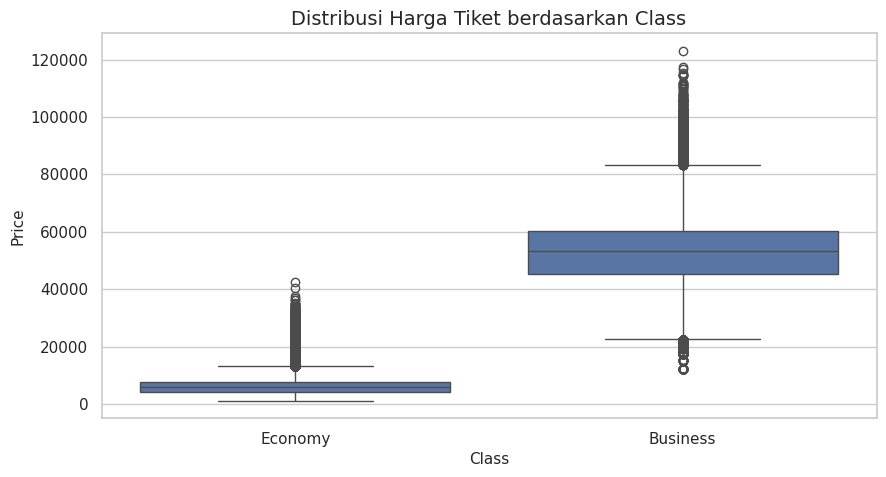

In [ ]:
class_summary = df_eda.groupby('class')['price'].agg(['count', 'mean', 'median', 'min', 'max'])
display(class_summary.style.format('{:,.0f}'))

sns.boxplot(data=df_eda, x='class', y='price')
plt.title('Distribusi Harga Tiket berdasarkan Class')
plt.xlabel('Class')
plt.ylabel('Price')
plt.show()

business_med = class_summary.loc['Business', 'median']
eco_med = class_summary.loc['Economy', 'median']
ratio = business_med / eco_med

Insight: Median harga Business sekitar 9 kali lebih mahal dibanding Economy. Hal ini menunjukkan bahwa class merupakan salah satu faktor paling kuat dalam membedakan harga tiket, karena Business class memiliki level harga jauh lebih tinggi dan rentang harga yang lebih lebar dibanding Economy.

## Efek Pemesanan Tiket Mendekati Hari-H (days_left vs price)

Sweet spot median harga termurah ada pada days_left = 47
Median price: 5,806


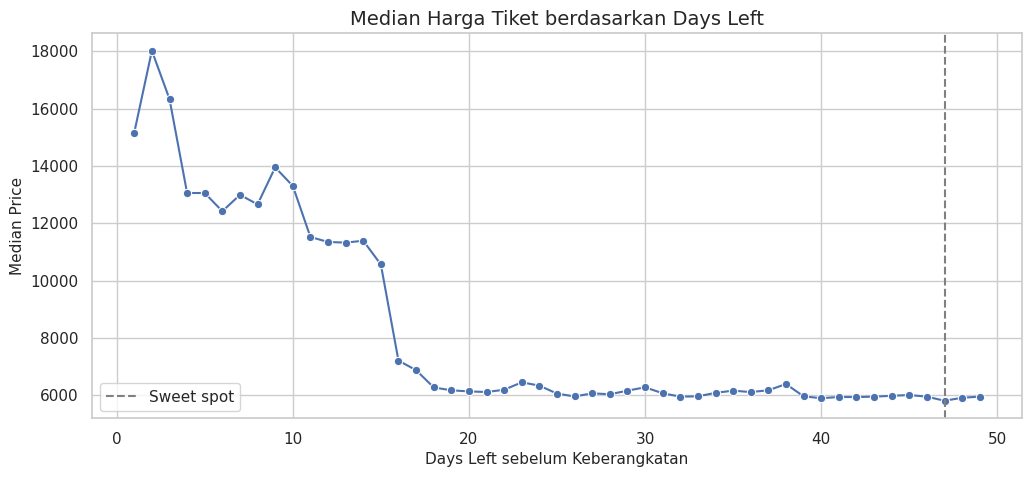

,median_price
booking_window,
1-7 days,"13,944"
8-14 days,"12,118"
15-30 days,"6,354"
31-49 days,"6,015"


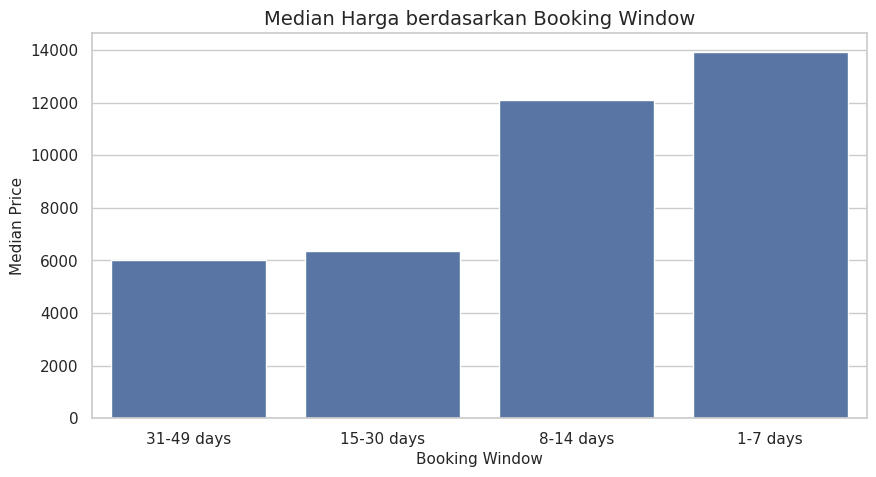

In [ ]:
days_summary = df_eda.groupby('days_left')['price'].median().reset_index()

days_summary = days_summary.sort_values(by='price')

sweet_spot = days_summary.loc[days_summary['price'].idxmin()]

print(f"Sweet spot median harga termurah ada pada days_left = {int(sweet_spot['days_left'])}")
print(f"Median price: {price_fmt(sweet_spot['price'])}")

plt.figure(figsize=(12, 5))
sns.lineplot(data=days_summary, x='days_left', y='price', marker='o')
plt.axvline(sweet_spot['days_left'], linestyle='--', color='gray', label='Sweet spot')
plt.title('Median Harga Tiket berdasarkan Days Left')
plt.xlabel('Days Left sebelum Keberangkatan')
plt.ylabel('Median Price')
plt.legend()
plt.show()

df_eda['booking_window'] = pd.cut(
    df_eda['days_left'],
    bins=[0, 7, 14, 30, 49],
    labels=['1-7 days', '8-14 days', '15-30 days', '31-49 days']
)

booking_summary = df_eda.groupby('booking_window', observed=False)['price'].median()
display(booking_summary.to_frame('median_price').style.format('{:,.0f}'))

sns.barplot(
    data=df_eda,
    x='booking_window',
    y='price',
    estimator=np.median,
    errorbar=None,
    order=booking_summary.sort_values().index
    )
plt.title('Median Harga berdasarkan Booking Window')
plt.xlabel('Booking Window')
plt.ylabel('Median Price')
plt.show()

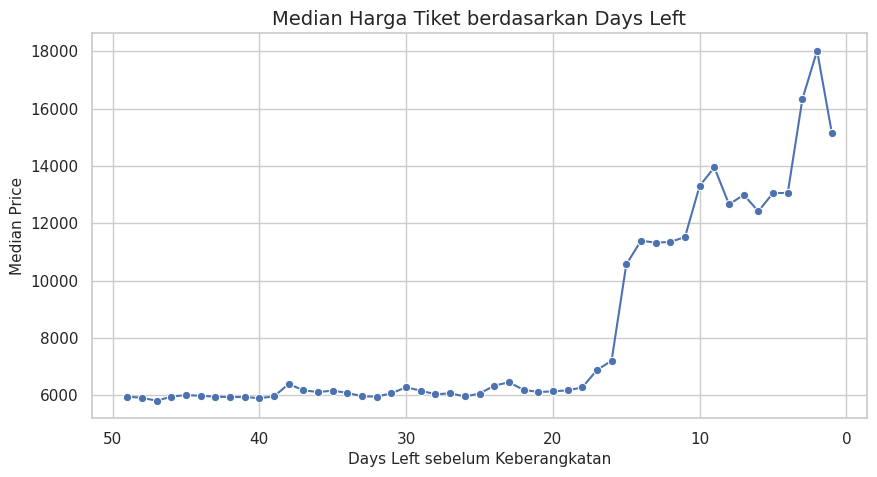

In [ ]:
median_days = df_eda.groupby('days_left')['price'].median().reset_index()

sns.lineplot(data=median_days, x='days_left', y='price', marker='o')

plt.gca().invert_xaxis()

plt.title('Median Harga Tiket berdasarkan Days Left')
plt.xlabel('Days Left sebelum Keberangkatan')
plt.ylabel('Median Price')
plt.show()

Insight: Harga tiket cenderung lebih tinggi ketika pembelian dilakukan mendekati hari keberangkatan, sehingga days_left dapat menjadi indikator penting dalam memahami pola perubahan harga. Penggunaan median membantu melihat harga tipikal dengan lebih stabil, sedangkan booking window mempermudah pembacaan tren harga tanpa harus melihat setiap nilai days_left satu per satu.

## Pengaruh Jumlah Transit terhadap Harga (stops vs price)

,count,median,mean
stops,,,
zero,"36,004","4,499","9,376"
one,"250,863","7,959","22,901"
two_or_more,"13,286","8,307","14,113"


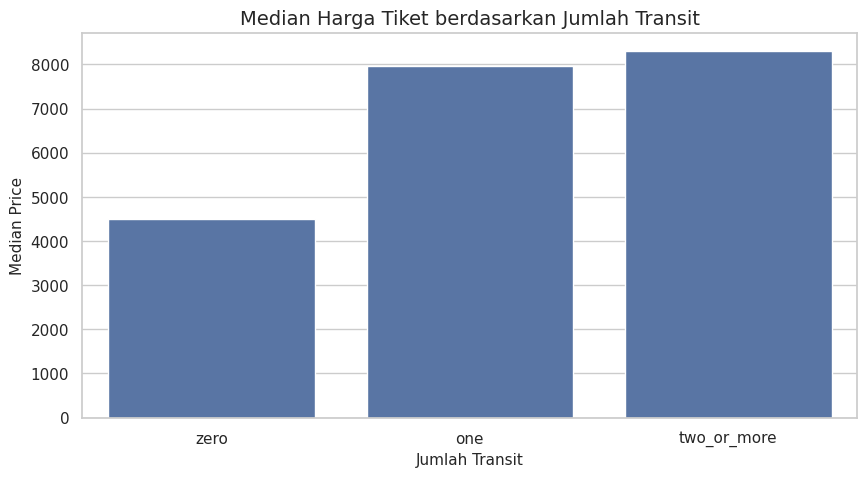

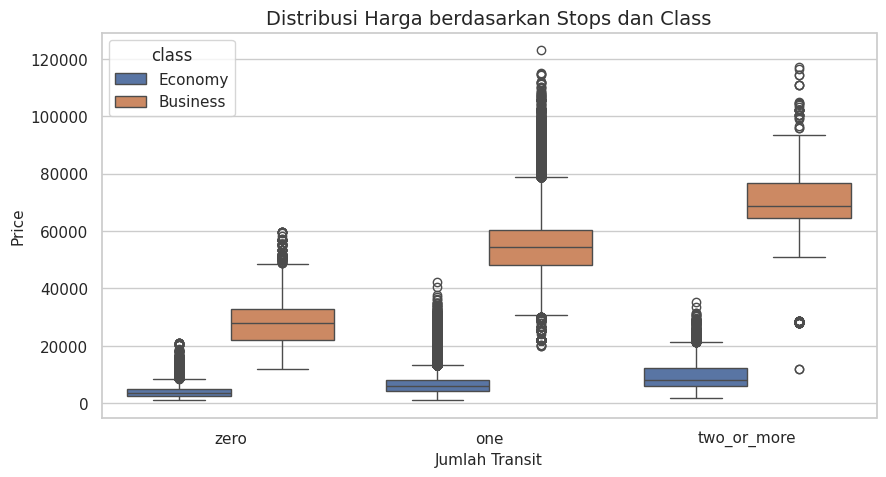

In [ ]:
stop_order = ['zero', 'one', 'two_or_more']

stops_summary = df_eda.groupby('stops')['price'].agg(['count', 'median', 'mean']).reindex(stop_order)
display(stops_summary.style.format('{:,.0f}'))

sns.barplot(
    data=df_eda,
    x='stops',
    y='price',
    order=stop_order,
    estimator=np.median,
    errorbar=None
)
plt.title('Median Harga Tiket berdasarkan Jumlah Transit')
plt.xlabel('Jumlah Transit')
plt.ylabel('Median Price')
plt.show()

sns.boxplot(
    data=df_eda,
    x='stops',
    y='price',
    hue='class',
    order=stop_order
)
plt.title('Distribusi Harga berdasarkan Stops dan Class')
plt.xlabel('Jumlah Transit')
plt.ylabel('Price')
plt.show()

Insight: Jumlah transit memiliki pengaruh terhadap harga tiket, namun efeknya perlu dibaca bersama variabel lain seperti class, route, dan duration. Direct flight tidak selalu otomatis paling mahal, tetapi kategori stops tetap penting karena berkaitan dengan kenyamanan perjalanan, waktu tempuh, dan preferensi penumpang.


## Popularitas Rute dan Dampaknya terhadap Harga (source_city & destination_city)

,route,total_flights,median_price
0,Delhi → Mumbai,15289,"7,262"
1,Mumbai → Delhi,14809,"6,300"
2,Delhi → Bangalore,14012,"6,642"
3,Bangalore → Delhi,13756,"7,164"
4,Bangalore → Mumbai,12939,"7,113"
5,Mumbai → Bangalore,12885,"7,192"
6,Mumbai → Kolkata,12602,"7,518"
7,Delhi → Kolkata,11934,"7,084"
8,Kolkata → Mumbai,11467,"7,958"
9,Delhi → Chennai,10780,"7,425"


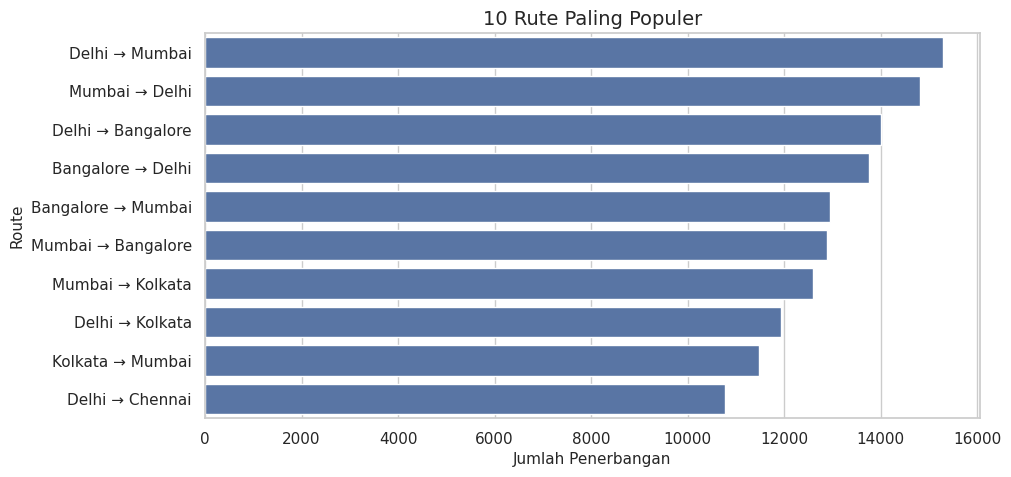

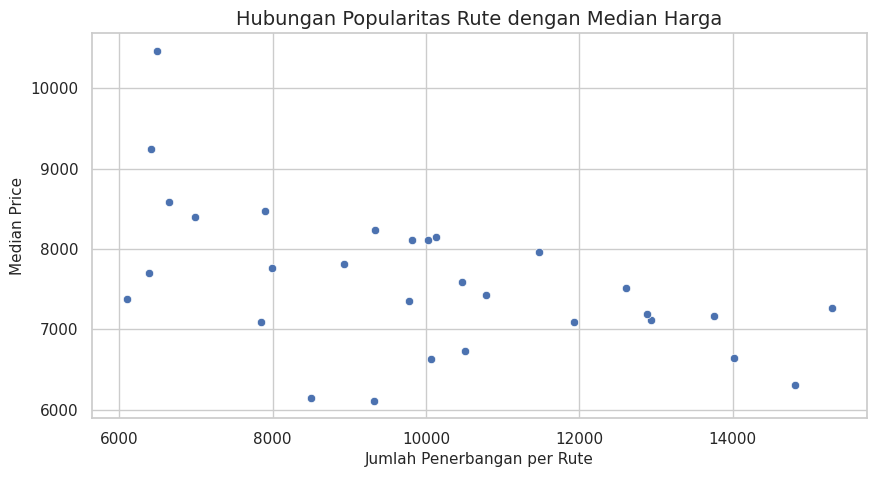

In [ ]:
route_summary = (
    df_eda.groupby('route')['price']
    .agg(total_flights='count', median_price='median')
    .sort_values('total_flights', ascending=False)
    .reset_index()
)

top_routes = route_summary.head(10)
display(top_routes.style.format({'median_price': '{:,.0f}'}))

sns.barplot(data=top_routes, y='route', x='total_flights')
plt.title('10 Rute Paling Populer')
plt.xlabel('Jumlah Penerbangan')
plt.ylabel('Route')
plt.show()

sns.scatterplot(data=route_summary, x='total_flights', y='median_price')
plt.title('Hubungan Popularitas Rute dengan Median Harga')
plt.xlabel('Jumlah Penerbangan per Rute')
plt.ylabel('Median Price')
plt.show()

Insight: Rute yang lebih populer menunjukkan demand dan aktivitas penerbangan yang tinggi, sehingga secara bisnis rute tersebut berpotensi memiliki harga yang lebih tinggi atau tetap kuat karena banyak diminati penumpang. Namun dari visualisasi scatter, hubungan popularitas rute dan median harga tidak sepenuhnya linear, sehingga harga rute tetap perlu dianalisis bersama faktor lain seperti class, airline, dan kompetisi antar maskapai.


## Korelasi Waktu Keberangkatan dan Kedatangan terhadap Harga (departure_time` & `arrival_time` vs `price)

Median price berdasarkan departure_time:


,median_price
departure_time,
Early_Morning,"7,212"
Morning,"8,112"
Afternoon,"6,663"
Evening,"7,425"
Night,"7,813"
Late_Night,"4,499"



Median price berdasarkan arrival_time:


,median_price
arrival_time,
Early_Morning,"5,800"
Morning,"7,687"
Afternoon,"6,714"
Evening,"8,854"
Night,"7,584"
Late_Night,"4,867"


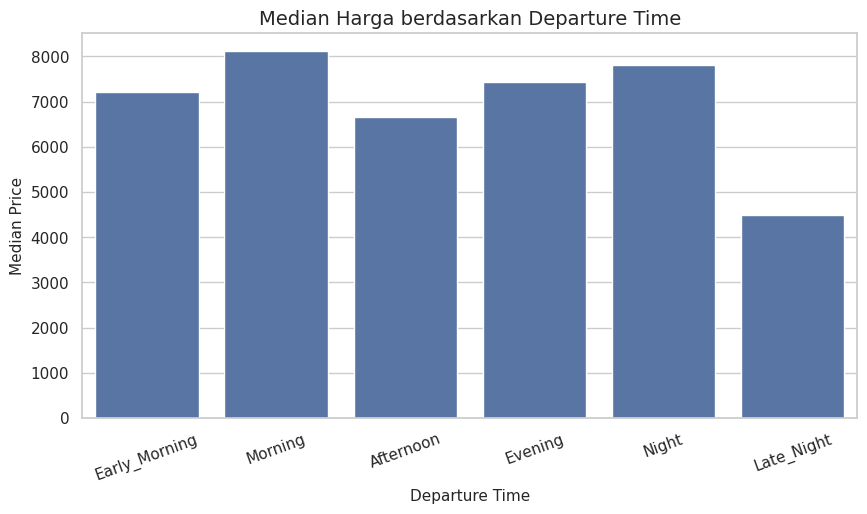

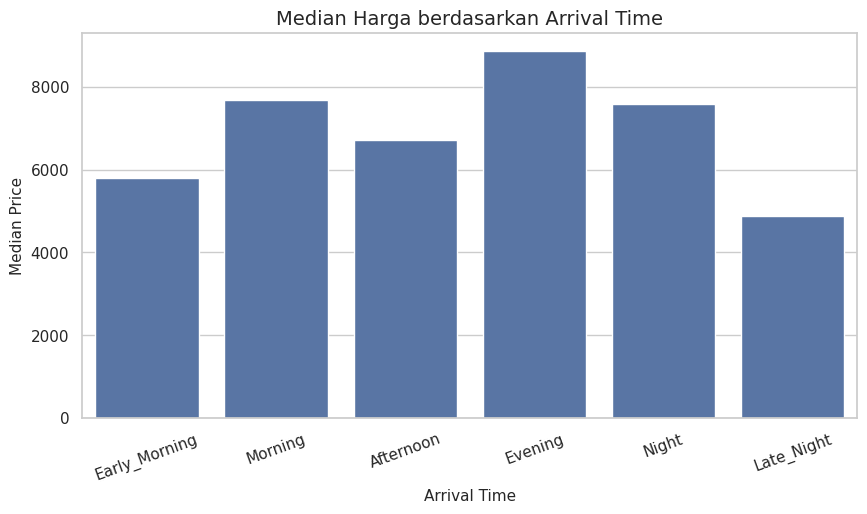

In [ ]:
dep_summary = df_eda.groupby('departure_time')['price'].median().reindex(time_order)
arr_summary = df_eda.groupby('arrival_time')['price'].median().reindex(time_order)

print("Median price berdasarkan departure_time:")
display(dep_summary.to_frame('median_price').style.format('{:,.0f}'))

print("\nMedian price berdasarkan arrival_time:")
display(arr_summary.to_frame('median_price').style.format('{:,.0f}'))

sns.barplot(
    data=df_eda,
    x='departure_time',
    y='price',
    order=time_order,
    estimator=np.median,
    errorbar=None
)
plt.title('Median Harga berdasarkan Departure Time')
plt.xlabel('Departure Time')
plt.ylabel('Median Price')
plt.xticks(rotation=20)
plt.show()

sns.barplot(
    data=df_eda,
    x='arrival_time',
    y='price',
    order=time_order,
    estimator=np.median,
    errorbar=None
)
plt.title('Median Harga berdasarkan Arrival Time')
plt.xlabel('Arrival Time')
plt.ylabel('Median Price')
plt.xticks(rotation=20)
plt.show()

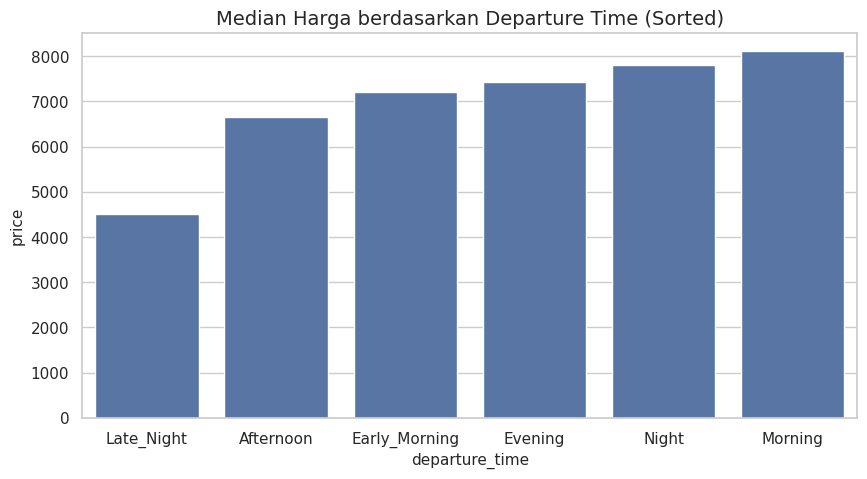

In [ ]:
median_dep = (
    df.groupby('departure_time')['price']
    .median()
    .sort_values()
    .reset_index()
)

sns.barplot(
    data=median_dep,
    x='departure_time',
    y='price',
    order=median_dep['departure_time']
)

plt.title('Median Harga berdasarkan Departure Time (Sorted)')
plt.show()

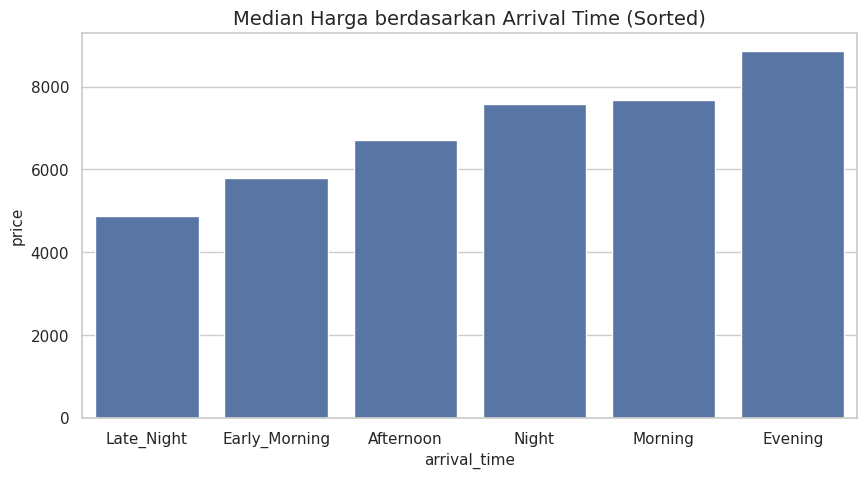

In [ ]:
median_arr = (
    df.groupby('arrival_time')['price']
    .median()
    .sort_values()
    .reset_index()
)

sns.barplot(
    data=median_arr,
    x='arrival_time',
    y='price',
    order=median_arr['arrival_time']
)

plt.title('Median Harga berdasarkan Arrival Time (Sorted)')
plt.show()

Insight: Waktu keberangkatan dan kedatangan memiliki pengaruh terhadap harga tiket karena berkaitan dengan kenyamanan dan preferensi jadwal penumpang. Beberapa periode waktu memiliki median harga lebih tinggi, sehingga departure_time dan arrival_time dapat menjadi fitur kategorikal yang relevan untuk memahami variasi harga.


## Perbandingan Airline terhadap Harga

,total_flights,median_price,mean_price
airline,,,
Vistara,"127,859","15,543","30,397"
Air_India,"80,892","11,520","23,507"
SpiceJet,"9,011","5,654","6,179"
GO_FIRST,"23,173","5,336","5,652"
Indigo,"43,120","4,453","5,324"
AirAsia,"16,098","3,276","4,091"


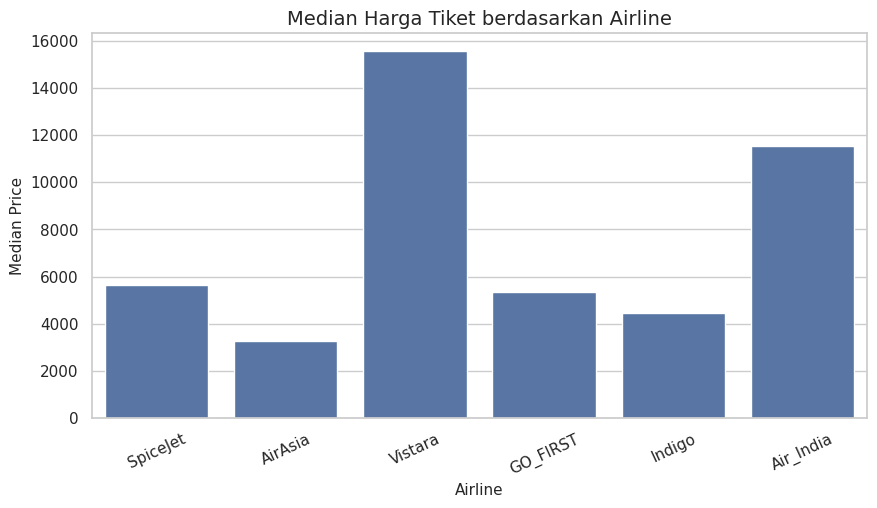

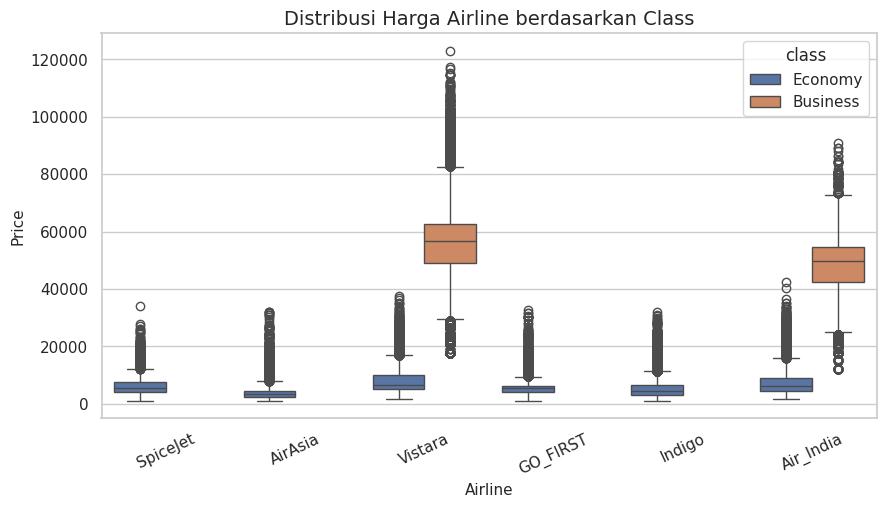

In [ ]:
airline_summary = (
    df_eda.groupby('airline')['price']
    .agg(total_flights='count', median_price='median', mean_price='mean')
    .sort_values('median_price', ascending=False)
)

display(airline_summary.style.format('{:,.0f}'))

sns.barplot(
    data=df_eda,
    x='airline',
    y='price',
    estimator=np.median,
    errorbar=None
)
plt.title('Median Harga Tiket berdasarkan Airline')
plt.xlabel('Airline')
plt.ylabel('Median Price')
plt.xticks(rotation=25)
plt.show()

sns.boxplot(data=df_eda, x='airline', y='price', hue='class')
plt.title('Distribusi Harga Airline berdasarkan Class')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.xticks(rotation=25)
plt.show()

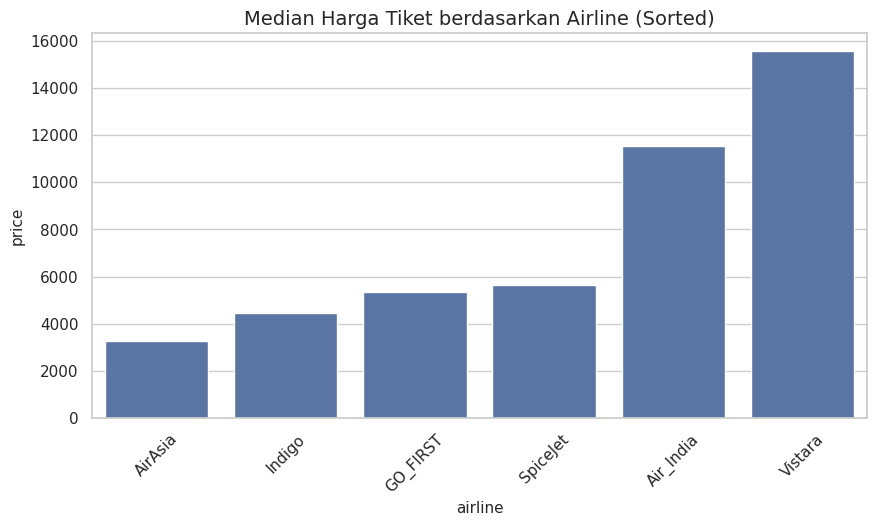

In [ ]:
median_airline = (
    df.groupby('airline')['price']
    .median()
    .sort_values()
    .reset_index()
)

sns.barplot(
    data=median_airline,
    x='airline',
    y='price',
    order=median_airline['airline']
)

plt.xticks(rotation=45)
plt.title('Median Harga Tiket berdasarkan Airline (Sorted)')
plt.show()

Insight: Setiap airline memiliki pola harga yang berbeda, sehingga maskapai dapat menjadi salah satu faktor penting dalam prediksi harga tiket. Perbandingan antar airline tetap perlu dilihat bersama class, karena perbedaan proporsi Economy dan Business dapat membuat median harga suatu maskapai terlihat lebih tinggi atau lebih rendah.


## Durasi Penerbangan terhadap Harga (duration vs price)

,count,median,mean
duration_category,,,
Short,"35,811","4,498","9,365"
Medium,"60,763","6,032","15,439"
Long,"127,279","8,186","23,896"
Very Long,"76,300","11,508","25,625"


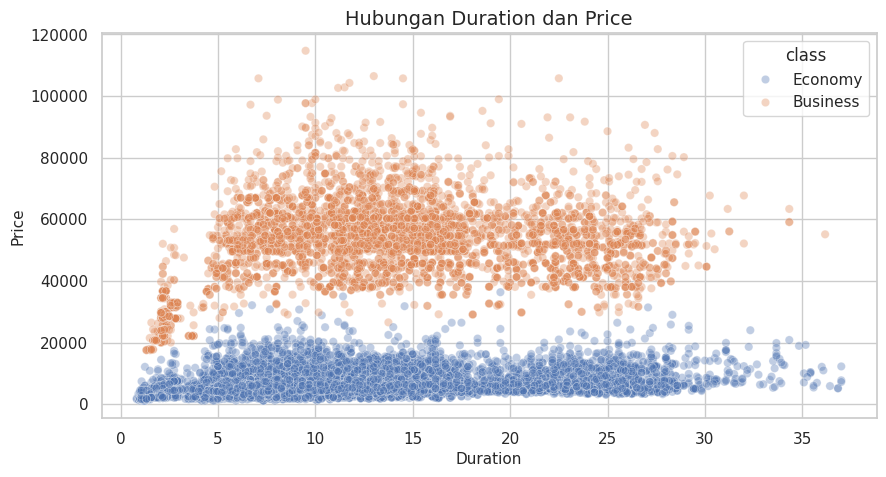

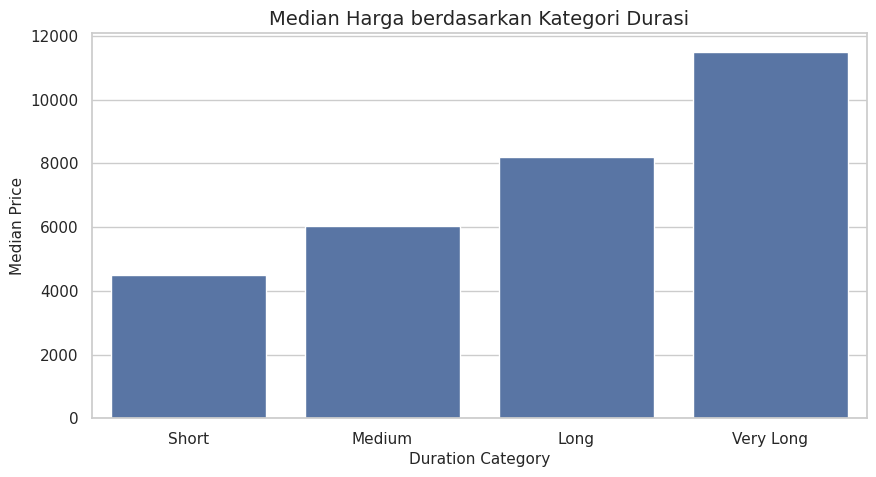

In [ ]:
df_eda['duration_category'] = pd.cut(
    df_eda['duration'],
    bins=[0, 3, 8, 16, df_eda['duration'].max()],
    labels=['Short', 'Medium', 'Long', 'Very Long'],
    include_lowest=True
)

duration_summary = (
    df_eda.groupby('duration_category', observed=False)['price']
    .agg(['count', 'median', 'mean'])
)

display(duration_summary.style.format('{:,.0f}'))

sample_df = df_eda.sample(n=15000, random_state=42)

sns.scatterplot(data=sample_df, x='duration', y='price', hue='class', alpha=0.35)
plt.title('Hubungan Duration dan Price')
plt.xlabel('Duration')
plt.ylabel('Price')
plt.show()

sns.barplot(
    data=df_eda,
    x='duration_category',
    y='price',
    estimator=np.median,
    errorbar=None
)
plt.title('Median Harga berdasarkan Kategori Durasi')
plt.xlabel('Duration Category')
plt.ylabel('Median Price')
plt.show()

Insight: Durasi penerbangan memiliki hubungan dengan harga, tetapi polanya tidak selalu linear karena durasi panjang dapat disebabkan oleh rute yang jauh atau waktu transit yang lama. Oleh karena itu, analisis duration sebaiknya dibaca bersama variabel lain seperti stops, route, dan class agar interpretasinya lebih tepat.


# Preparing Data for Modeling

In [ ]:
# Ringkasan jumlah unique values setiap kolom
unique_summary = pd.DataFrame({
    'column': df.columns,
    'unique_count': df.nunique().values
})

unique_summary

,column,unique_count
0,index,300153
1,airline,6
2,flight,1561
3,source_city,6
4,departure_time,6
5,stops,3
6,arrival_time,6
7,destination_city,6
8,class,2
9,duration,476


In [ ]:
# Melihat unique values untuk kolom bertipe object/kategorikal
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"Unique values pada kolom '{col}':")
    print(df[col].unique())
    print(" ")

Unique values pada kolom 'airline':
['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
 
Unique values pada kolom 'flight':
['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433']
 
Unique values pada kolom 'source_city':
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
 
Unique values pada kolom 'departure_time':
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
 
Unique values pada kolom 'stops':
['zero' 'one' 'two_or_more']
 
Unique values pada kolom 'arrival_time':
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
 
Unique values pada kolom 'destination_city':
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
 
Unique values pada kolom 'class':
['Economy' 'Business']
 


## Split Dataset

In [ ]:
# Membuat copy dataframe untuk proses modeling
df_model = df_eda.copy(deep=True)

print("Shape df_eda:", df_eda.shape)
print("Shape df_model:", df_model.shape)

display(df_model.head())

Shape df_eda: (300153, 15)
Shape df_model: (300153, 15)


,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,route,booking_window,duration_category
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,Delhi → Mumbai,1-7 days,Short
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,Delhi → Mumbai,1-7 days,Short
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,Delhi → Mumbai,1-7 days,Short
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,Delhi → Mumbai,1-7 days,Short
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,Delhi → Mumbai,1-7 days,Short


In [ ]:
# Drop kolom yang tidak digunakan untuk modeling
df_model = df_model.drop(
    columns=['index', 'flight', 'source_city', 'destination_city', 'booking_window', 'duration_category']
)

# Cek kolom yang tersisa
print(df_model.columns)

# Pisahkan fitur dan target
X = df_model.drop(columns=['price'])
y = df_model['price']

display(df_model.head())

Index(['airline', 'departure_time', 'stops', 'arrival_time', 'class',
       'duration', 'days_left', 'price', 'route'],
      dtype='object')


,airline,departure_time,stops,arrival_time,class,duration,days_left,price,route
0,SpiceJet,Evening,zero,Night,Economy,2.17,1,5953,Delhi → Mumbai
1,SpiceJet,Early_Morning,zero,Morning,Economy,2.33,1,5953,Delhi → Mumbai
2,AirAsia,Early_Morning,zero,Early_Morning,Economy,2.17,1,5956,Delhi → Mumbai
3,Vistara,Morning,zero,Afternoon,Economy,2.25,1,5955,Delhi → Mumbai
4,Vistara,Morning,zero,Morning,Economy,2.33,1,5955,Delhi → Mumbai


In [ ]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['price'])
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (240122, 8)
X_test shape : (60031, 8)
y_train shape: (240122,)
y_test shape : (60031,)


## Label Encoding, One Hot Encoding, dan Standarisasi

In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Define the column lists
numeric_cols = [
    'duration',
    'days_left'
]

ordinal_cols = [
    'stops',
    'class'
]

nominal_cols = [
    'airline',
    'route',
    'departure_time',
    'arrival_time'
]

ordinal_categories = [
    ['zero', 'one', 'two_or_more'],
    ['Economy', 'Business']
]

In [ ]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numeric_cols),
        ('ordinal', OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ('nominal', OneHotEncoder(handle_unknown='ignore'), nominal_cols)
    ],
    remainder='drop'
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('numerical', 'passthrough', numeric_cols),
        ('ordinal', OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ('nominal', OneHotEncoder(handle_unknown='ignore'), nominal_cols)
    ],
    remainder='drop'
)

# Modeling

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_regression_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2
    }

In [ ]:
def safe_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    if np.sum(mask) == 0:
        return np.nan

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def evaluate_regression_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = safe_mape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2
    }

In [ ]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## Linear Regression Model

In [ ]:
pipeline_linear = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('model', LinearRegression())
])

pipeline_linear.fit(X_train, y_train)

y_pred_linear = pipeline_linear.predict(X_test)

result_linear = evaluate_regression_model(
    'Linear Regression',
    y_test,
    y_pred_linear
)

result_linear

{'Model': 'Linear Regression',
 'MAE': 4501.350223918018,
 'RMSE': np.float64(6778.750148351038),
 'MAPE (%)': np.float64(43.52997658937646),
 'R²': 0.9108573545009987}

## Ridge Regression Model

In [ ]:
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('model', Ridge(alpha=1.0, random_state=42))
])

pipeline_ridge.fit(X_train, y_train)

y_pred_ridge = pipeline_ridge.predict(X_test)

result_ridge = evaluate_regression_model(
    'Ridge Regression',
    y_test,
    y_pred_ridge
)

result_ridge

{'Model': 'Ridge Regression',
 'MAE': 4501.2063891443,
 'RMSE': np.float64(6778.75696407827),
 'MAPE (%)': np.float64(43.52410823241267),
 'R²': 0.9108571752430976}

## LASSO Regression Model

In [ ]:
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('model', Lasso(alpha=0.001, random_state=42, max_iter=10000))
])

pipeline_lasso.fit(X_train, y_train)

y_pred_lasso = pipeline_lasso.predict(X_test)

result_lasso = evaluate_regression_model(
    'Lasso Regression',
    y_test,
    y_pred_lasso
)

result_lasso

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 91306687977.51367, tolerance: 12368998390.903316
  model = cd_fast.sparse_enet_coordinate_descent(


{'Model': 'Lasso Regression',
 'MAE': 4501.345673980048,
 'RMSE': np.float64(6778.750246814044),
 'MAPE (%)': np.float64(43.529857852834944),
 'R²': 0.9108573519113612}

## ElasticNet Regression

In [ ]:
pipeline_elasticnet = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('model', ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        random_state=42,
        max_iter=10000
    ))
])

pipeline_elasticnet.fit(X_train, y_train)

y_pred_elasticnet = pipeline_elasticnet.predict(X_test)

result_elasticnet = evaluate_regression_model(
    'ElasticNet Regression',
    y_test,
    y_pred_elasticnet
)

result_elasticnet

{'Model': 'ElasticNet Regression',
 'MAE': 4497.870339975435,
 'RMSE': np.float64(6778.831950781199),
 'MAPE (%)': np.float64(43.400810383199826),
 'R²': 0.9108552030338781}

## Decision Tree Model

In [ ]:
pipeline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('model', DecisionTreeRegressor(
        max_depth=15,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ))
])

pipeline_tree.fit(X_train, y_train)

y_pred_tree = pipeline_tree.predict(X_test)

result_tree = evaluate_regression_model(
    'Decision Tree',
    y_test,
    y_pred_tree
)

result_tree

{'Model': 'Decision Tree',
 'MAE': 2389.3344390545603,
 'RMSE': np.float64(4487.413574580815),
 'MAPE (%)': np.float64(15.212960751623255),
 'R²': 0.9609358427596023}

## Random Forest Model

In [ ]:
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_rf.fit(X_train, y_train)

y_pred_rf = pipeline_rf.predict(X_test)

result_rf = evaluate_regression_model(
    'Random Forest',
    y_test,
    y_pred_rf
)

result_rf

{'Model': 'Random Forest',
 'MAE': 1990.0780787530996,
 'RMSE': np.float64(3907.793113231952),
 'MAPE (%)': np.float64(12.52325744226584),
 'R²': 0.9703756117352059}

## XGBoost Regression Model

In [ ]:
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_xgb.fit(X_train, y_train)

y_pred_xgb = pipeline_xgb.predict(X_test)

result_xgb = evaluate_regression_model(
    'XGBoost',
    y_test,
    y_pred_xgb
)

result_xgb

{'Model': 'XGBoost',
 'MAE': 2024.4010009765625,
 'RMSE': np.float64(3615.6356287657086),
 'MAPE (%)': np.float64(14.235140493553672),
 'R²': 0.9746396541595459}

### !! Optimalization XGBoost with Hyperparameter Tuning



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

param_dist = {
    'model__n_estimators': [100, 200, 300, 500, 800],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
    'model__max_depth': [3, 4, 5, 6, 8, 10],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__gamma': [0, 0.1, 0.3, 0.5],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [1, 1.5, 2, 3]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test)

result_best_xgb = evaluate_regression_model(
    'Best XGBoost',
    y_test,
    y_pred_best_xgb
)

print("Best parameters:")
print(xgb_search.best_params_)

result_best_xgb

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters:
{'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__reg_alpha': 0.1, 'model__n_estimators': 800, 'model__min_child_weight': 3, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}


{'Model': 'Best XGBoost',
 'MAE': 1312.680419921875,
 'RMSE': np.float64(2582.021107582198),
 'MAPE (%)': np.float64(9.839429099606791),
 'R²': 0.9870668053627014}

### XGBoost with Parameters

In [ ]:
final_xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('model', XGBRegressor(
        n_estimators=800,
        learning_rate=0.1,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=2,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

final_xgb_model.fit(X_train, y_train)

y_pred_final_xgb = final_xgb_model.predict(X_test)

result_final_xgb = evaluate_regression_model(
    'Final XGBoost',
    y_test,
    y_pred_final_xgb
)

result_final_xgb

{'Model': 'Final XGBoost',
 'MAE': 1312.680419921875,
 'RMSE': np.float64(2582.021107582198),
 'MAPE (%)': np.float64(9.839429099606791),
 'R²': 0.9870668053627014}

## LightGBM Regression

In [ ]:
pipeline_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('model', LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_lgbm.fit(X_train, y_train)

y_pred_lgbm = pipeline_lgbm.predict(X_test)

result_lgbm = evaluate_regression_model(
    'LightGBM',
    y_test,
    y_pred_lgbm
)

result_lgbm

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006481 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 240122, number of used features: 53
[LightGBM] [Info] Start training from score 20888.572417


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'Model': 'LightGBM',
 'MAE': 2106.0318889180485,
 'RMSE': np.float64(3627.0360843734825),
 'MAPE (%)': np.float64(16.152027156539436),
 'R²': 0.9744794507359725}

### !! Optimalization LightGBM with Hyperparameter Tuning

In [ ]:
# Pipeline LightGBM
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('model', LGBMRegressor(
        objective='regression',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

# Parameter search space LightGBM
param_dist_lgbm = {
    'model__n_estimators': [100, 300, 500, 800, 1000],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'model__max_depth': [-1, 3, 5, 7, 10],
    'model__num_leaves': [15, 31, 50, 70, 100],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'model__min_child_samples': [10, 20, 30, 50],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [0, 0.01, 0.1, 1, 2]
}

# Randomized Search LightGBM
lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=param_dist_lgbm,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit tuning
lgbm_search.fit(X_train, y_train)

# Best model
best_lgbm = lgbm_search.best_estimator_

# Prediction
y_pred_best_lgbm = best_lgbm.predict(X_test)

# Evaluation
result_best_lgbm = evaluate_regression_model(
    'Best LightGBM',
    y_test,
    y_pred_best_lgbm
)

print("Best CV RMSE:", -lgbm_search.best_score_)
print("Best parameters:")
print(lgbm_search.best_params_)

result_best_lgbm

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Best CV RMSE: 2710.3853130280672
Best parameters:
{'model__subsample': 0.9, 'model__reg_lambda': 2, 'model__reg_alpha': 0.01, 'model__num_leaves': 100, 'model__n_estimators': 1000, 'model__min_child_samples': 10, 'model__max_depth': -1, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}


{'Model': 'Best LightGBM',
 'MAE': 1355.6747175990747,
 'RMSE': np.float64(2633.9887504324065),
 'MAPE (%)': np.float64(10.456472460528868),
 'R²': 0.9865409596156025}

### LightGBM with Parameters

In [ ]:
final_lgbm_model = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled),
    ('model', LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=100,
        subsample=0.9,
        colsample_bytree=0.7,
        min_child_samples=10,
        reg_alpha=0.01,
        reg_lambda=2,
        objective='regression',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ))
])

final_lgbm_model.fit(X_train, y_train)

y_pred_final_lgbm = final_lgbm_model.predict(X_test)

result_final_lgbm = evaluate_regression_model(
    'Final LightGBM',
    y_test,
    y_pred_final_lgbm
)

result_final_lgbm

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'Model': 'Final LightGBM',
 'MAE': 1355.6747175990747,
 'RMSE': np.float64(2633.9887504324065),
 'MAPE (%)': np.float64(10.456472460528868),
 'R²': 0.9865409596156025}

## Metrics

In [ ]:
results = [
    result_linear,
    result_ridge,
    result_lasso,
    result_elasticnet,
    result_tree,
    result_rf,
    result_xgb,
    result_best_xgb,
    result_lgbm,
    result_best_lgbm
]

metrics_df = pd.DataFrame(results)

metrics_df = metrics_df.sort_values(
    by='RMSE',
    ascending=True
).reset_index(drop=True)

In [ ]:
metrics_df_styled = metrics_df.style \
    .format({
        'MAE': '{:,.2f}',
        'RMSE': '{:,.2f}',
        'MAPE (%)': '{:.2f}%',
        'R²': '{:.4f}'
    }) \
    .highlight_min(subset=['MAE', 'RMSE', 'MAPE (%)'], color='blue') \
    .highlight_max(subset=['R²'], color='green') \
    .set_caption('Perbandingan Performa Model Regresi')

display(metrics_df_styled)

,Model,MAE,RMSE,MAPE (%),R²
0,Best XGBoost,"1,312.68","2,582.02",9.84%,0.9871
1,Best LightGBM,"1,355.67","2,633.99",10.46%,0.9865
2,XGBoost,"2,024.40","3,615.64",14.24%,0.9746
3,LightGBM,"2,106.03","3,627.04",16.15%,0.9745
4,Random Forest,"1,990.08","3,907.79",12.52%,0.9704
5,Decision Tree,"2,389.33","4,487.41",15.21%,0.9609
6,Linear Regression,"4,501.35","6,778.75",43.53%,0.9109
7,Lasso Regression,"4,501.35","6,778.75",43.53%,0.9109
8,Ridge Regression,"4,501.21","6,778.76",43.52%,0.9109
9,ElasticNet Regression,"4,497.87","6,778.83",43.40%,0.9109


In [ ]:
trained_models = {
    'Linear Regression': pipeline_linear,
    'Ridge Regression': pipeline_ridge,
    'Lasso Regression': pipeline_lasso,
    'ElasticNet Regression': pipeline_elasticnet,
    'Decision Tree': pipeline_tree,
    'Random Forest': pipeline_rf,
    'XGBoost': pipeline_xgb,
    'Best XGBoost': best_xgb,
    'LightGBM': pipeline_lgbm
}

In [ ]:
best_model_name = metrics_df.loc[0, 'Model']
best_model_pipeline = trained_models[best_model_name]

print("Best Model:", best_model_name)
display(metrics_df.head())

Best Model: Best XGBoost


,Model,MAE,RMSE,MAPE (%),R²
0,Best XGBoost,1312.680420,2582.021108,9.839429,0.987067
1,Best LightGBM,1355.674718,2633.988750,10.456472,0.986541
2,XGBoost,2024.401001,3615.635629,14.235140,0.974640
3,LightGBM,2106.031889,3627.036084,16.152027,0.974479
4,Random Forest,1990.078079,3907.793113,12.523257,0.970376


### Evaluasi Overfitting atau Underfitting

In [ ]:
# Prediksi pada data train dan test
y_train_pred_best_xgb = best_xgb.predict(X_train)
y_test_pred_best_xgb = best_xgb.predict(X_test)

# Evaluasi train
result_train_best_xgb = evaluate_regression_model(
    'Best XGBoost - Train',
    y_train,
    y_train_pred_best_xgb
)

# Evaluasi test
result_test_best_xgb = evaluate_regression_model(
    'Best XGBoost - Test',
    y_test,
    y_test_pred_best_xgb
)

In [ ]:
overfit_check_df = pd.DataFrame([
    result_train_best_xgb,
    result_test_best_xgb
])

overfit_check_df

,Model,MAE,RMSE,MAPE (%),R²
0,Best XGBoost - Train,1123.042114,2123.438014,8.799793,0.991247
1,Best XGBoost - Test,1312.680420,2582.021108,9.839429,0.987067


# Conclusion

In [ ]:
import joblib

joblib.dump(best_model_pipeline, 'best_flight_price_model.pkl')

print("Model berhasil disimpan sebagai best_flight_price_model.pkl")

Model berhasil disimpan sebagai best_flight_price_model.pkl


# Try with New Data

In [ ]:
new_data = pd.DataFrame({
    'airline': ['Vistara'],
    'departure_time': ['Evening'],
    'stops': ['one'],
    'arrival_time': ['Evening'],
    'class': ['Economy'],
    'duration': [2.17],
    'days_left': [20],
    'route': ['Delhi → Mumbai']
})

In [ ]:
predicted_price_xgboost = final_xgb_model.predict(new_data)

print(f"Predicted ticket price: {predicted_price_xgboost[0]:,.2f}")

Predicted ticket price: 3,080.86


# Membandingkan Data Aktual dan Prediksi

In [ ]:
prediction_result = pd.DataFrame({
    'Actual Price': y_test.reset_index(drop=True),
    'Predicted Price': y_pred_final_xgb
})

prediction_result['Error'] = prediction_result['Actual Price'] - prediction_result['Predicted Price']
prediction_result['Absolute Error'] = abs(prediction_result['Error'])
prediction_result['Percentage Error (%)'] = (
    prediction_result['Absolute Error'] / prediction_result['Actual Price']
) * 100

prediction_result.head(10)

,Actual Price,Predicted Price,Error,Absolute Error,Percentage Error (%)
0,7366,7028.366211,337.633789,337.633789,4.583679
1,64831,67605.554688,-2774.554688,2774.554688,4.279673
2,6195,6371.534180,-176.534180,176.534180,2.849624
3,60160,60376.992188,-216.992188,216.992188,0.360692
4,6578,6759.523926,-181.523926,181.523926,2.759561
5,4555,7013.227539,-2458.227539,2458.227539,53.967674
6,23838,23312.644531,525.355469,525.355469,2.203857
7,3860,3711.841797,148.158203,148.158203,3.838295
8,32230,48754.300781,-16524.300781,16524.300781,51.269937
9,76841,66892.476562,9948.523438,9948.523438,12.946895
